# 4. Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import patsy
import missingno as msno

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("crest", 8)
plt.rcParams["figure.dpi"] = 110

In [3]:
from tools.recode import recode, clean_recode

def parse(var: str) -> None:
    """
    Details of a variable (displayed simply)
    """
    var_dict = recode.get(var, None) or clean_recode.get(var, None)
    if not var_dict:
        print("Variable not found in the recode list!")
        return None

    print(f"Name: {var_dict['name']}")
    value = var_dict.get("value", None)
    if value is None:
        print("Value: Continuous variable")
        return None
    print(f"Categories: ")
    for i, j in value.items():
        print(f"\t{i}: {j}")

In [ ]:
df = pd.read_csv("../resources/depression-anxiety-dataset.csv")
print("Shape:", df.shape)
df.head()

df_depression: (4887, 36)
df_anxiety:   (4887, 36)


,Cardiometabolic Burden,Diabetes,Hypertension,Obesity,Cardiometabolic Burden Merged,Cardiometabolic Burden Binary,Socioeconomic Status,Depression,Anxiety,Depression Binary,Anxiety Binary,Education,Occupation,Partner occupation,Age,Age at first cohabitation,Division,Residence,Religion,Children,Family size,Household Autonomy,Financial Decision-Making,IPV Attitude,Insurance,Mass Media,Contraceptive,Abortion,Pregnant,Menopause,Sexual activity,Postpartum,CASEID,Sampling weight,PSU,Stratum
0,3,1,1,1,2,1,5,1,1,0,0,3,0.0,1,3,1,1,1,1,2,1,3,1,0,0.0,1.0,0.0,1,0,0,0,0,1 1 3,0.156207,1,1
1,0,0,0,0,0,0,4,1,1,0,0,0,1.0,2,3,1,1,1,2,1,1,3,0,0,0.0,0.0,2.0,0,0,0,1,0,1 18 2,0.156207,1,1
2,0,0,0,0,0,0,4,0,0,0,0,2,1.0,2,1,0,1,1,1,1,1,0,0,0,0.0,1.0,0.0,0,1,0,1,0,1 35 2,0.156207,1,1
3,0,0,0,0,0,0,4,0,0,0,0,2,0.0,2,2,1,1,1,2,0,1,3,0,0,0.0,2.0,0.0,0,0,0,1,0,1 52 2,0.156207,1,1
4,0,0,0,0,0,0,5,0,0,0,0,2,0.0,2,3,0,1,1,2,1,1,3,0,0,0.0,1.0,0.0,1,0,0,0,0,1 69 2,0.156207,1,1


## Survey Design Overview

In [ ]:
design_summary = pd.DataFrame({
    "n_obs": [len(df)],
    "unique_PSU": [df["PSU"].nunique()],
    "unique_Stratum": [df["Stratum"].nunique()],
    "weight_min": [df["Sampling weight"].min()],
    "weight_max": [df["Sampling weight"].max()],
    "weight_mean": [df["Sampling weight"].mean()],
    "sum_of_weights": [df["Sampling weight"].sum()],
})
design_summary.index = ["depression sample"]
design_summary

,n_obs,unique_PSU,unique_Stratum,weight_min,weight_max,weight_mean,sum_of_weights
depression sample,4887,674,16,0.091325,3.891736,0.992805,4851.835617


In [ ]:
w = df["Sampling weight"].values
deff_weighting = (len(w) * np.sum(w**2)) / (np.sum(w)**2)
n_eff = len(w) / deff_weighting
print(f"Weighting-only design effect (Kish):  {deff_weighting:.3f}")
print(f"Implied effective sample size:        {n_eff:,.0f}  (of {len(w):,} nominal)")

cluster_sizes = df.groupby("PSU").size()
print(f"\nClusters: {df['PSU'].nunique()}, smallest cluster: {cluster_sizes.min()} respondents")

Weighting-only design effect (Kish):  1.253
Implied effective sample size:        3,901  (of 4,887 nominal)

Clusters: 674, smallest cluster: 2 respondents


## Missingness: Structural Sub-Sampling vs. Item-Level

In [7]:
raw = pd.read_csv("../resources/full_dataset.csv")
raw = raw[raw["S111A"] == 1]
print("Eligible currently-married women (pre-completeness-filter):", raw.shape[0])

diabetes_cols   = ["SB267", "SB236", "SB240"]
hyper_cols      = ["WBP24", "WBP25", "WBP16", "WBP19"]
obesity_cols    = ["HA40"]

biomarker_incomplete = (
    (raw[diabetes_cols].isna().sum(axis=1) >= 3) |
    (raw[hyper_cols].isna().sum(axis=1) >= 4) |
    (raw[obesity_cols].isna().sum(axis=1) >= 1)
)

depression_missing = raw["MTH22"].isna()
occ_ins_abuse_missing = raw[["V744A","V744B","V744C","V744D","V744E"]].isna().all(axis=1)
autonomy_partner_missing = raw[["V743A","V743B","V743D"]].isna().all(axis=1)

overlap = pd.DataFrame({
    "block size": [depression_missing.sum(), occ_ins_abuse_missing.sum(), autonomy_partner_missing.sum()],
    "within biomarker-incomplete": [
        (depression_missing & biomarker_incomplete).sum(),
        (occ_ins_abuse_missing & biomarker_incomplete).sum(),
        (autonomy_partner_missing & biomarker_incomplete).sum(),
    ],
}, index=["Depression/Anxiety (MTH22/24) missing", "Occupation+Insurance+Abuse-attitudes missing (all-NaN block)",
          "Household-decision items (V743A/B/D) missing (all-NaN block)"])
overlap["% explained by biomarker sub-sample"] = (overlap["within biomarker-incomplete"] / overlap["block size"] * 100).round(1)
overlap

Eligible currently-married women (pre-completeness-filter): 28537


,block size,within biomarker-incomplete,% explained by biomarker sub-sample
Depression/Anxiety (MTH22/24) missing,9550,9550,100.0
Occupation+Insurance+Abuse-attitudes missing (all-NaN block),9550,9550,100.0
Household-decision items (V743A/B/D) missing (all-NaN block),9550,9550,100.0


All the extended-module stuff (depression, occupation, insurance, IPV, household decisions) is missing for the same women who lack biomarkers. And since we're only keeping currently-married women now, there's no separate "not married" reason for the household-decision missingness, it's purely the module.

### Analytic sample vs. eligible population

The biomarker-completeness filter drops 23,650 of the 28,537 eligible women -- worth checking
directly whether the 4,887 who remain still look like the eligible population on the variables that
matter most for this analysis (wealth, age, division), or whether the biomarker sub-sample skews
sharply on any of them.

In [ ]:
raw_elig = raw.copy()
raw_elig["Sampling weight"] = raw_elig["V005"] / 1_000_000
raw_elig["in_analytic_sample"] = raw_elig["CASEID"].isin(df["CASEID"])

# Standard-questionnaire variables recoded to their clean_recode categories
raw_elig["age_grp"] = pd.cut(raw_elig["V012"], bins=[14, 24, 34, 49],
                             labels=["15-24", "25-34", "35-49"])
raw_elig["children_grp"] = raw_elig["V201"].clip(upper=4)
raw_elig["family_size_grp"] = np.where(raw_elig["V136"] < 5, 1, 2)

wealth_map      = {1: "Poorest", 2: "Poorer", 3: "Middle", 4: "Richer", 5: "Richest"}
division_map    = {1: "Barishal", 2: "Chattogram", 3: "Dhaka", 4: "Khulna",
                   5: "Mymensingh", 6: "Rajshahi", 7: "Rangpur", 8: "Sylhet"}
education_map   = {0: "No education", 1: "Primary", 2: "Secondary", 3: "Higher"}
residence_map   = {1: "Urban", 2: "Rural"}
religion_map    = {1: "Islam", 2: "Others"}
children_map    = {0: "None", 1: "1", 2: "2", 3: "3", 4: "4+"}
family_size_map = {1: "<5", 2: "5+"}

def weighted_pct(data, col, mapping=None):
    g = data.groupby(col, dropna=False)["Sampling weight"].sum()
    pct = (g / g.sum() * 100).round(1)
    if mapping:
        pct.index = [mapping.get(i, i) for i in pct.index]
    return pct

# Every covariate measured on the full eligible population. Variables that
# share the extended-module missingness (Section 2) are excluded by construction.
checkable = [
    ("Wealth quintile", "V190",             wealth_map),
    ("Age group",       "age_grp",          None),
    ("Division",        "V024",             division_map),
    ("Education",       "V106",             education_map),
    ("Residence",       "V025",             residence_map),
    ("Religion",        "V130",             religion_map),
    ("Children",        "children_grp",     children_map),
    ("Family size",     "family_size_grp",  family_size_map),
]

rows = []
for label, col, mapping in checkable:
    elig     = weighted_pct(raw_elig, col, mapping)
    analytic = weighted_pct(raw_elig[raw_elig["in_analytic_sample"]], col, mapping)
    for cat in elig.index:
        rows.append({"Variable": label, "Category": cat,
                     "Eligible (n=28,537) %": elig.get(cat),
                     "Analytic (n=4,887) %": analytic.get(cat)})

compare_df = pd.DataFrame(rows)
compare_df["Difference (pp)"] = (
    compare_df["Analytic (n=4,887) %"] - compare_df["Eligible (n=28,537) %"]
).round(1)

print(f"max absolute diff over {len(compare_df)} categories: "
      f"{compare_df['Difference (pp)'].abs().max():.1f} pp")
compare_df

max absolute diff over 34 categories: 2.2 pp


,Variable,Category,"Eligible (n=28,537) %","Analytic (n=4,887) %",Difference (pp)
0,Wealth quintile,Poorest,18.2,17.5,-0.7
1,Wealth quintile,Poorer,20.1,20.0,-0.1
2,Wealth quintile,Middle,20.4,20.1,-0.3
3,Wealth quintile,Richer,20.7,20.8,0.1
4,Wealth quintile,Richest,20.6,21.7,1.1
5,Age group,15-24,25.6,23.4,-2.2
6,Age group,25-34,35.2,35.5,0.3
7,Age group,35-49,39.2,41.1,1.9
8,Division,Barishal,6.1,6.4,0.3
9,Division,Chattogram,18.5,19.1,0.6


Adding Education, Residence, Religion, Children, and Family size doesn't change the picture: across all 34 categories, no difference exceeds 2.2 percentage points. Wealth, Residence, and Family size are flat to within about a point; Division and Education top out at 1.1; Religion at 0.5. The two variables that move — Age (15-24 down 2.2, 35-49 up 1.9) and Children (none down 1.9, 4+ up 1.8) — move together and in the expected direction, which is one story rather than two: older and more parous women were the ones more likely to complete the biomarker module, and parity is mechanically tied to age. All eight variables here are covariates in every model, so this residual tilt is the kind of thing adjustment already handles.

Occupation (V714), Partner occupation (V704), Household Autonomy (V743A/B/D), Insurance (V481), and Mass Media (V171A, V159) don't appear in the table for the same reason they don't appear anywhere else in the analysis: they share the extended-module missingness documented in Section 2, so there is no value on the eligible-only side to compare against. Their absence from this check is the selection mechanism itself, not an omission.

One bookkeeping note: the Religion map only covers V130 codes 1 (Islam) and 2 (Others), so codes 3, 4, and 96 print as raw integers. Together they are 1.4% of the eligible sample and neither the eligible nor analytic share moves by more than 0.1 points, so the read doesn't change — but the map should be extended to mirror `religion()` before the table goes into a supplement.

## 3. Univariate Distributions (Design-Weighted)

In [9]:
def weighted_props(data, col, weight_col="Sampling weight"):
    g = data.groupby(col, dropna=False)[weight_col].sum()
    return (g / g.sum() * 100).sort_index()

def unweighted_props(data, col):
    g = data[col].value_counts(dropna=False)
    return (g / g.sum() * 100).sort_index()

def compare_bar(data, col, ax, title=None, labels=None):
    w = weighted_props(data, col)
    u = unweighted_props(data, col)
    idx = w.index
    x = np.arange(len(idx))
    width = 0.38
    ax.bar(x - width/2, u.reindex(idx).values, width, label="Unweighted", color=PALETTE[2])
    ax.bar(x + width/2, w.reindex(idx).values, width, label="Weighted (V005)", color=PALETTE[6])
    ax.set_xticks(x)
    tick_labels = [labels[i] for i in idx] if labels else [str(i) for i in idx]
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_ylabel("%")
    ax.set_title(title or col)
    ax.legend(fontsize=8)

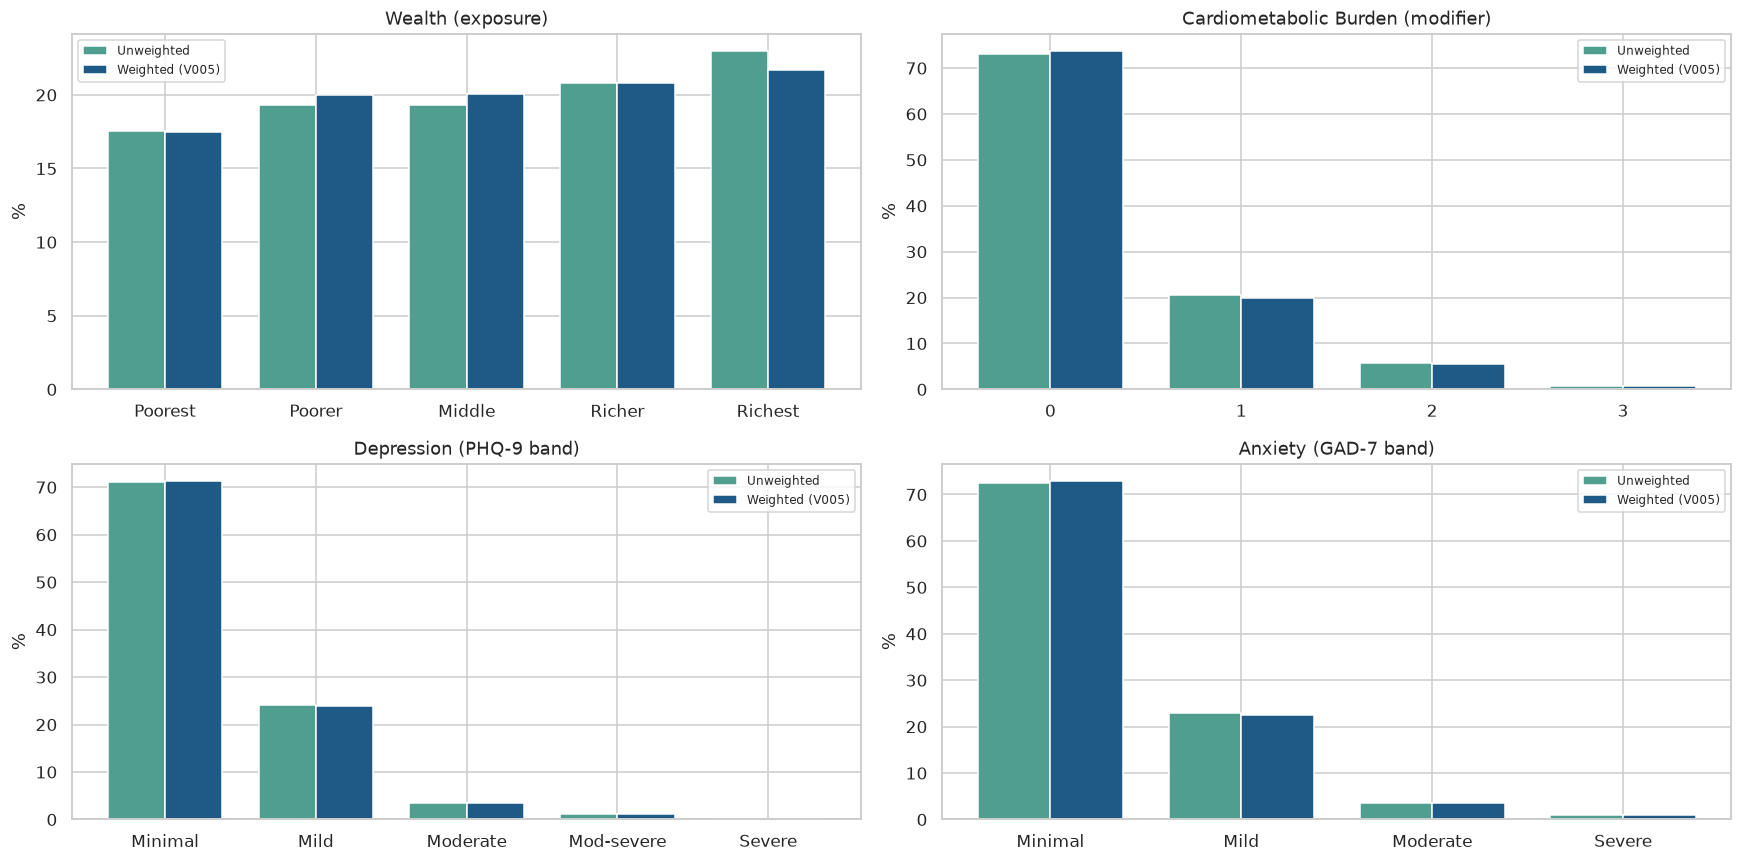

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

compare_bar(df, "Socioeconomic Status", axes[0,0], "Wealth (exposure)",
            {1:"Poorest",2:"Poorer",3:"Middle",4:"Richer",5:"Richest"})
compare_bar(df, "Cardiometabolic Burden", axes[0,1], "Cardiometabolic Burden (modifier)",
            {0:"0",1:"1",2:"2",3:"3"})
compare_bar(df, "Depression", axes[1,0], "Depression (PHQ-9 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Mod-severe",4:"Severe"})
compare_bar(df, "Anxiety", axes[1,1], "Anxiety (GAD-7 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Severe"})

plt.tight_layout()
plt.show()

Survey weights are not reshaping the core distributions (for four variables that matter most)

In [ ]:
import statsmodels.api as sm

def weighted_prevalence_ci(data, outcome_col, weight_col="Sampling weight", cluster_col="PSU"):
    y = data[outcome_col].values.astype(float)
    w = data[weight_col].values
    X = np.ones((len(y), 1))
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model = sm.GLM(y, X, family=sm.families.Gaussian(), var_weights=w)
        res = model.fit(cov_type="cluster", cov_kwds={"groups": data[cluster_col].values})
    est = float(np.asarray(res.params)[0])
    ci = np.asarray(res.conf_int())
    return est, ci[0, 0], ci[0, 1]

df["Depression_binary"] = (df["Depression"] >= 2).astype(int)
df["Anxiety_binary"] = (df["Anxiety"] >= 2).astype(int)

for label, data, col in [("Depression", df, "Depression_binary"), ("Anxiety", df, "Anxiety_binary")]:
    unweighted = data[col].mean()
    est, lo, hi = weighted_prevalence_ci(data, col)
    print(f"{label}: unweighted {unweighted:.1%}  |  weighted {est:.1%}  (95% CI {lo:.1%}-{hi:.1%}, cluster-robust by PSU)")

Depression: unweighted 4.8%  |  weighted 4.8%  (95% CI 4.0%-5.5%, cluster-robust by PSU)
Anxiety: unweighted 4.5%  |  weighted 4.6%  (95% CI 3.8%-5.3%, cluster-robust by PSU)


Weighted and unweighted prevalence land within a few tenths of a point of each other for both outcomes, so the survey weights aren't dragging the headline numbers around — the sample was already close to representative on these measures. The more useful number here is the interval width: roughly ±0.75 points on each side, cluster-robust, which is the honest precision behind "4.8%" and "4.6%." That width is the reason Notebook 5 treats individual coefficients cautiously — a rare outcome with a CI this wide doesn't leave much room to spare once it's split across dozens of model parameters. Note the CIs overlap between depression and anxiety, so we should not describe one as more prevalent than the other.

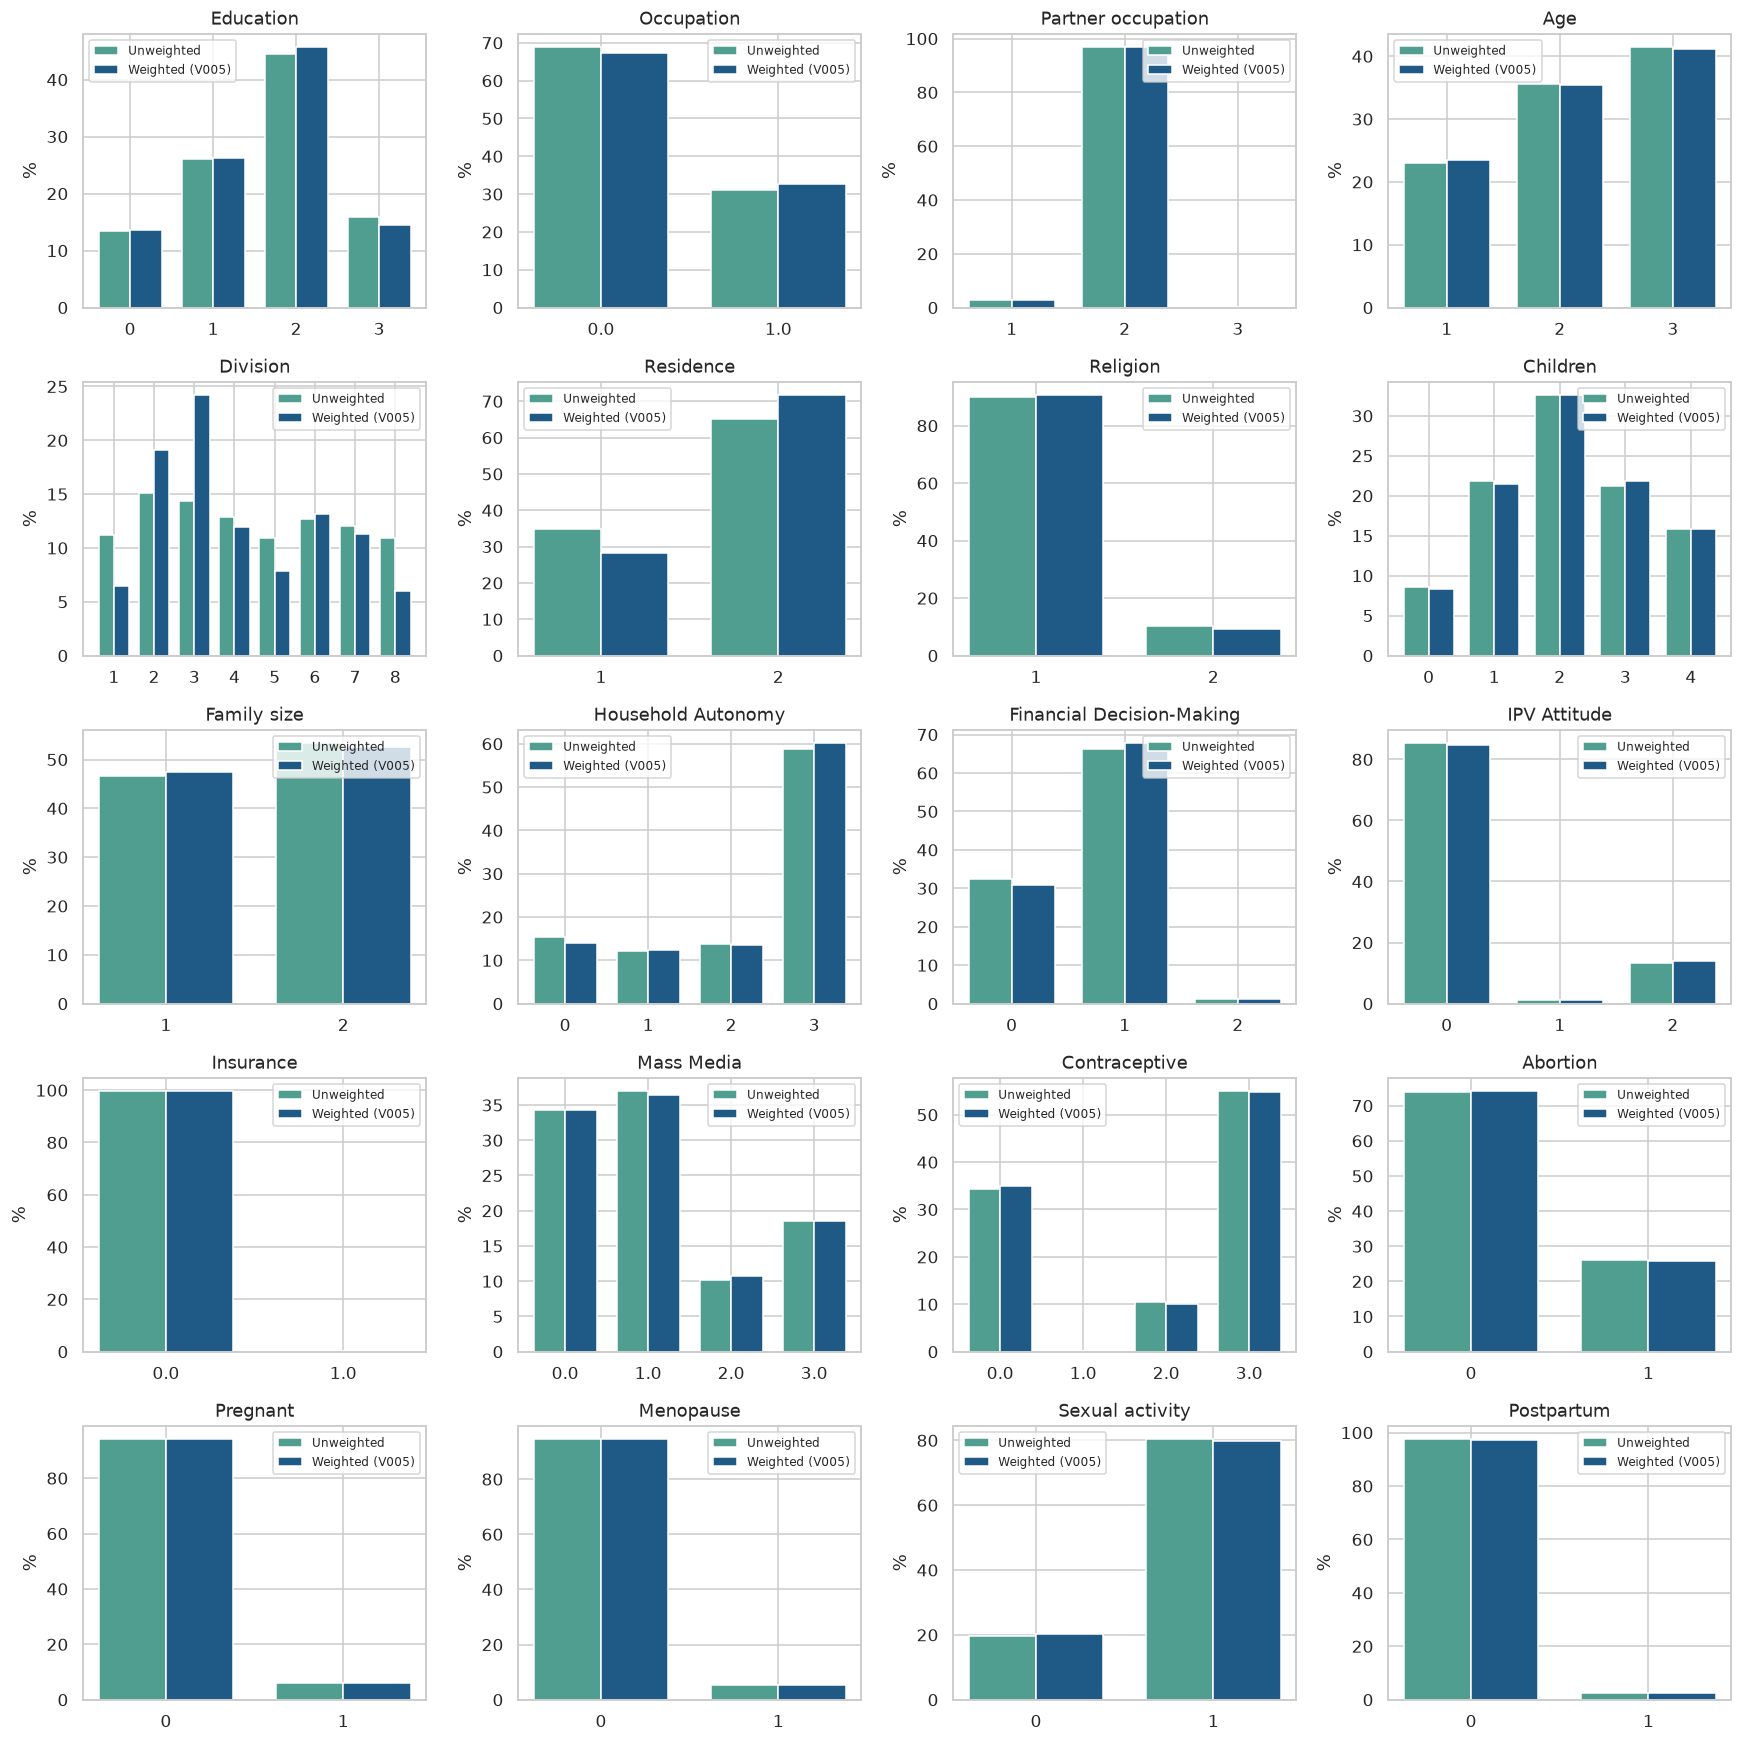

In [ ]:
confounders = ["Education", "Occupation", "Partner occupation", "Age", "Division", "Residence", "Religion", "Children", "Family size", "Household Autonomy", "Financial Decision-Making", "IPV Attitude", "Insurance", "Mass Media", "Contraceptive", "Abortion", "Pregnant", "Menopause", "Sexual activity", "Postpartum"]

fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(confounders):
    compare_bar(df, col, axes[i], col)
for j in range(len(confounders), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

In [13]:
parse("Division")
print("-"*40,"\n")
parse("Residence")

Name: Division
Categories: 
	1: Barishal
	2: Chattogram
	3: Dhaka
	4: Khulna
	5: Mymensingh
	6: Rajshahi
	7: Rangpur
	8: Sylhet
---------------------------------------- 

Name: Type of place of residence
Categories: 
	1: Urban
	2: Rural


`Division` and `Residence` are the two panels where weighted and unweighted bars visibly diverge — expected, since geographic strata are exactly what DHS oversamples by design. The weights are doing real work here: unweighted division shares describe our sample, not the population. This is the clearest evidence in the grid that weighting is necessary, and it's also the reason cluster-robust SEs (PSUs are geographically clustered) matter for anything division-related. Note this is a different concern from Section 2.2: there, analytic vs eligible looked balanced on division; here, we're comparing sample design vs the true population, and those are never the same by construction.

## Bivariate Relationships and Cell Sparsity

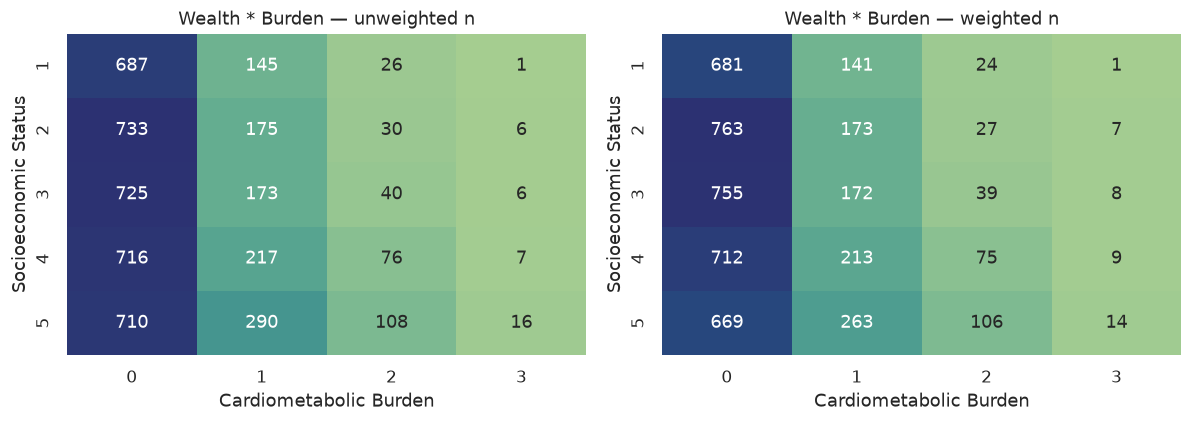

Smallest unweighted cell: 1


In [ ]:
ct_unweighted = pd.crosstab(df["Socioeconomic Status"], df["Cardiometabolic Burden"])
ct_weighted = df.pivot_table(index="Socioeconomic Status", columns="Cardiometabolic Burden",
                                         values="Sampling weight", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(ct_unweighted, annot=True, fmt="d", cmap="crest", ax=axes[0], cbar=False)
axes[0].set_title("Wealth * Burden — unweighted n")
sns.heatmap(ct_weighted, annot=True, fmt=".0f", cmap="crest", ax=axes[1], cbar=False)
axes[1].set_title("Wealth * Burden — weighted n")
plt.tight_layout()
plt.show()

print("Smallest unweighted cell:", ct_unweighted.values.min())

Sparsity concern: the highest-burden, lowest-wealth cell remains thin. We should treat `Cardiometabolic Burden` as ordinal rather than fitting a fully saturated categorical interaction.

In [ ]:
cell3 = df.groupby(["Socioeconomic Status", "Cardiometabolic Burden", "Depression"]).size()
print(f"3-way cells: {len(cell3)} total, {int((cell3 == 0).sum())} empty, "
      f"\nminimum non-empty count = {cell3[cell3 > 0].min()}")
print(f"Cells with count < 5: {int((cell3 < 5).sum())} out of {len(cell3)}")

3-way cells: 70 total, 0 empty, 
minimum non-empty count = 1
Cells with count < 5: 23 out of 70


Fitting a fully saturated 3-way interaction (Wealth * Burden * Depression, with all categories free) is not going to work — nearly a third of the cells would be estimated from 1–4 people.

In [ ]:
def naive_chi2(data, a, b, label):
    tab = pd.crosstab(data[a], data[b])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    print(f"{label:35s}  chi2={chi2:8.2f}  df={dof:3d}  p={p:.4g}")

print("Design-naive Pearson chi-sq screening (NOT the reported statistic):\n")
naive_chi2(df, "Socioeconomic Status", "Cardiometabolic Burden", "Wealth * Burden")
naive_chi2(df, "Socioeconomic Status", "Depression", "Wealth * Depression")
naive_chi2(df, "Cardiometabolic Burden", "Depression", "Burden * Depression")
naive_chi2(df, "Socioeconomic Status", "Anxiety", "Wealth * Anxiety")
naive_chi2(df, "Cardiometabolic Burden", "Anxiety", "Burden * Anxiety")

Design-naive Pearson chi-sq screening (NOT the reported statistic):

Wealth * Burden                      chi2=  123.67  df= 12  p=1.145e-20
Wealth * Depression                  chi2=   31.71  df= 16  p=0.01089
Burden * Depression                  chi2=   14.86  df= 12  p=0.2493
Wealth * Anxiety                     chi2=   41.80  df= 12  p=3.602e-05
Burden * Anxiety                     chi2=   17.54  df=  9  p=0.04092


- Wealth and Burden are strongly associated (p ≈ 10⁻²⁰) — richer women carry far fewer cardiometabolic conditions, as expected.
- Wealth is modestly associated with both outcomes (p = 0.011 depression, p ≈ 4×10⁻⁵ anxiety).
- Burden alone shows **no** marginal association with either outcome (p = 0.25 depression, p = 0.04 anxiety — borderline, and would likely slip further under a design-aware test). Burden doesn't move the average outcome, but Wealth does. If Burden still matters, it's as an effect modifier — changing how strongly Wealth relates to mental health — not as a main-effect predictor. Which is exactly the hypothesis in this project.

## Multicollinearity: Generalized VIF

In [ ]:
def calc_gvif(formula_rhs, data):
    '''Fox & Monette (1992) generalized VIF, one row per term.'''
    design = patsy.dmatrix(formula_rhs, data, return_type="dataframe")
    term_slices = design.design_info.term_name_slices
    X = design.drop(columns=["Intercept"], errors="ignore")
    R = X.corr().values
    detR = np.linalg.det(R)
    colnames = list(X.columns)

    rows = []
    for term, sl in term_slices.items():
        if term == "Intercept":
            continue
        cols = [c for c in design.columns[sl] if c != "Intercept"]
        idx = [colnames.index(c) for c in cols]
        other_idx = [i for i in range(len(colnames)) if i not in idx]
        d = len(idx)
        gvif = (np.linalg.det(R[np.ix_(idx, idx)]) * np.linalg.det(R[np.ix_(other_idx, other_idx)])) / detR
        rows.append((term.replace("C(Q('", "").replace("'))", ""), d, gvif, gvif ** (1 / (2 * d))))
    out = pd.DataFrame(rows, columns=["term", "Df", "GVIF", "GVIF^(1/(2*Df))"])
    return out.sort_values("GVIF^(1/(2*Df))", ascending=False).reset_index(drop=True)

exposure, modifier = "Socioeconomic Status", "Cardiometabolic Burden"
model_vars = [exposure, modifier] + confounders
formula_rhs = " + ".join(f"C(Q('{v}'))" for v in model_vars)

gvif = calc_gvif(formula_rhs, df[model_vars].dropna())
threshold = 2.0
gvif["flag"] = np.where(gvif["GVIF^(1/(2*Df))"] > threshold, "Review", "OK")
gvif.style.format({"GVIF": "{:.3g}", "GVIF^(1/(2*Df))": "{:.3g}"})

,term,Df,GVIF,GVIF^(1/(2*Df)),flag
0,Age,2,2.35,1.24,OK
1,Sexual activity,1,1.36,1.17,OK
2,Financial Decision-Making,2,1.84,1.16,OK
3,Children,4,2.76,1.14,OK
4,Pregnant,1,1.27,1.12,OK
5,Residence,1,1.25,1.12,OK
6,Education,3,1.94,1.12,OK
7,Mass Media,3,1.89,1.11,OK
8,Menopause,1,1.24,1.11,OK
9,Contraceptive,3,1.81,1.1,OK


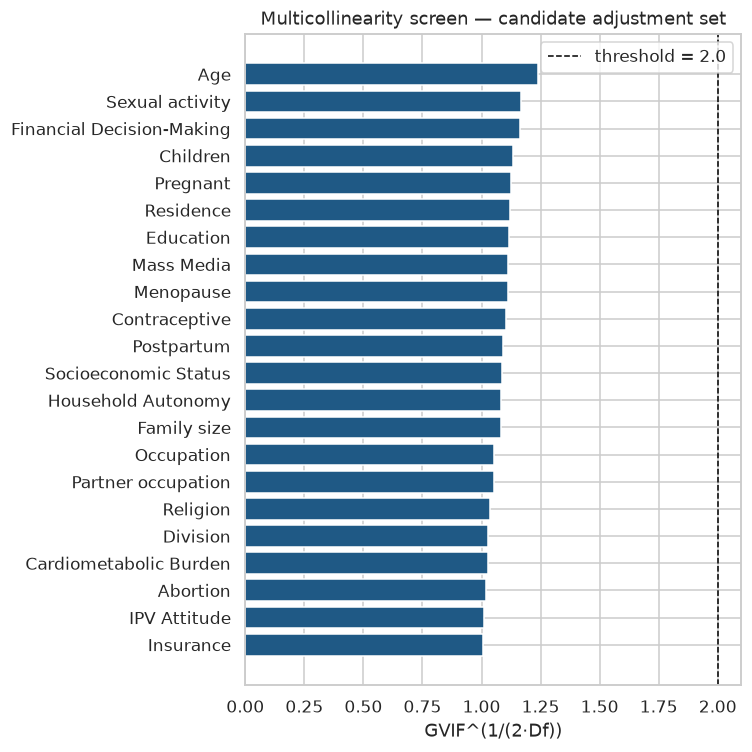

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))
order = gvif.sort_values("GVIF^(1/(2*Df))")
colors = [PALETTE[6] if v <= threshold else "indianred" for v in order["GVIF^(1/(2*Df))"]]
ax.barh(order["term"], order["GVIF^(1/(2*Df))"], color=colors)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold = {threshold}")
ax.set_xlabel("GVIF^(1/(2·Df))")
ax.set_title("Multicollinearity screen — candidate adjustment set")
ax.legend()
plt.tight_layout()
plt.show()

### Association overview (categorical correlation heatmap)

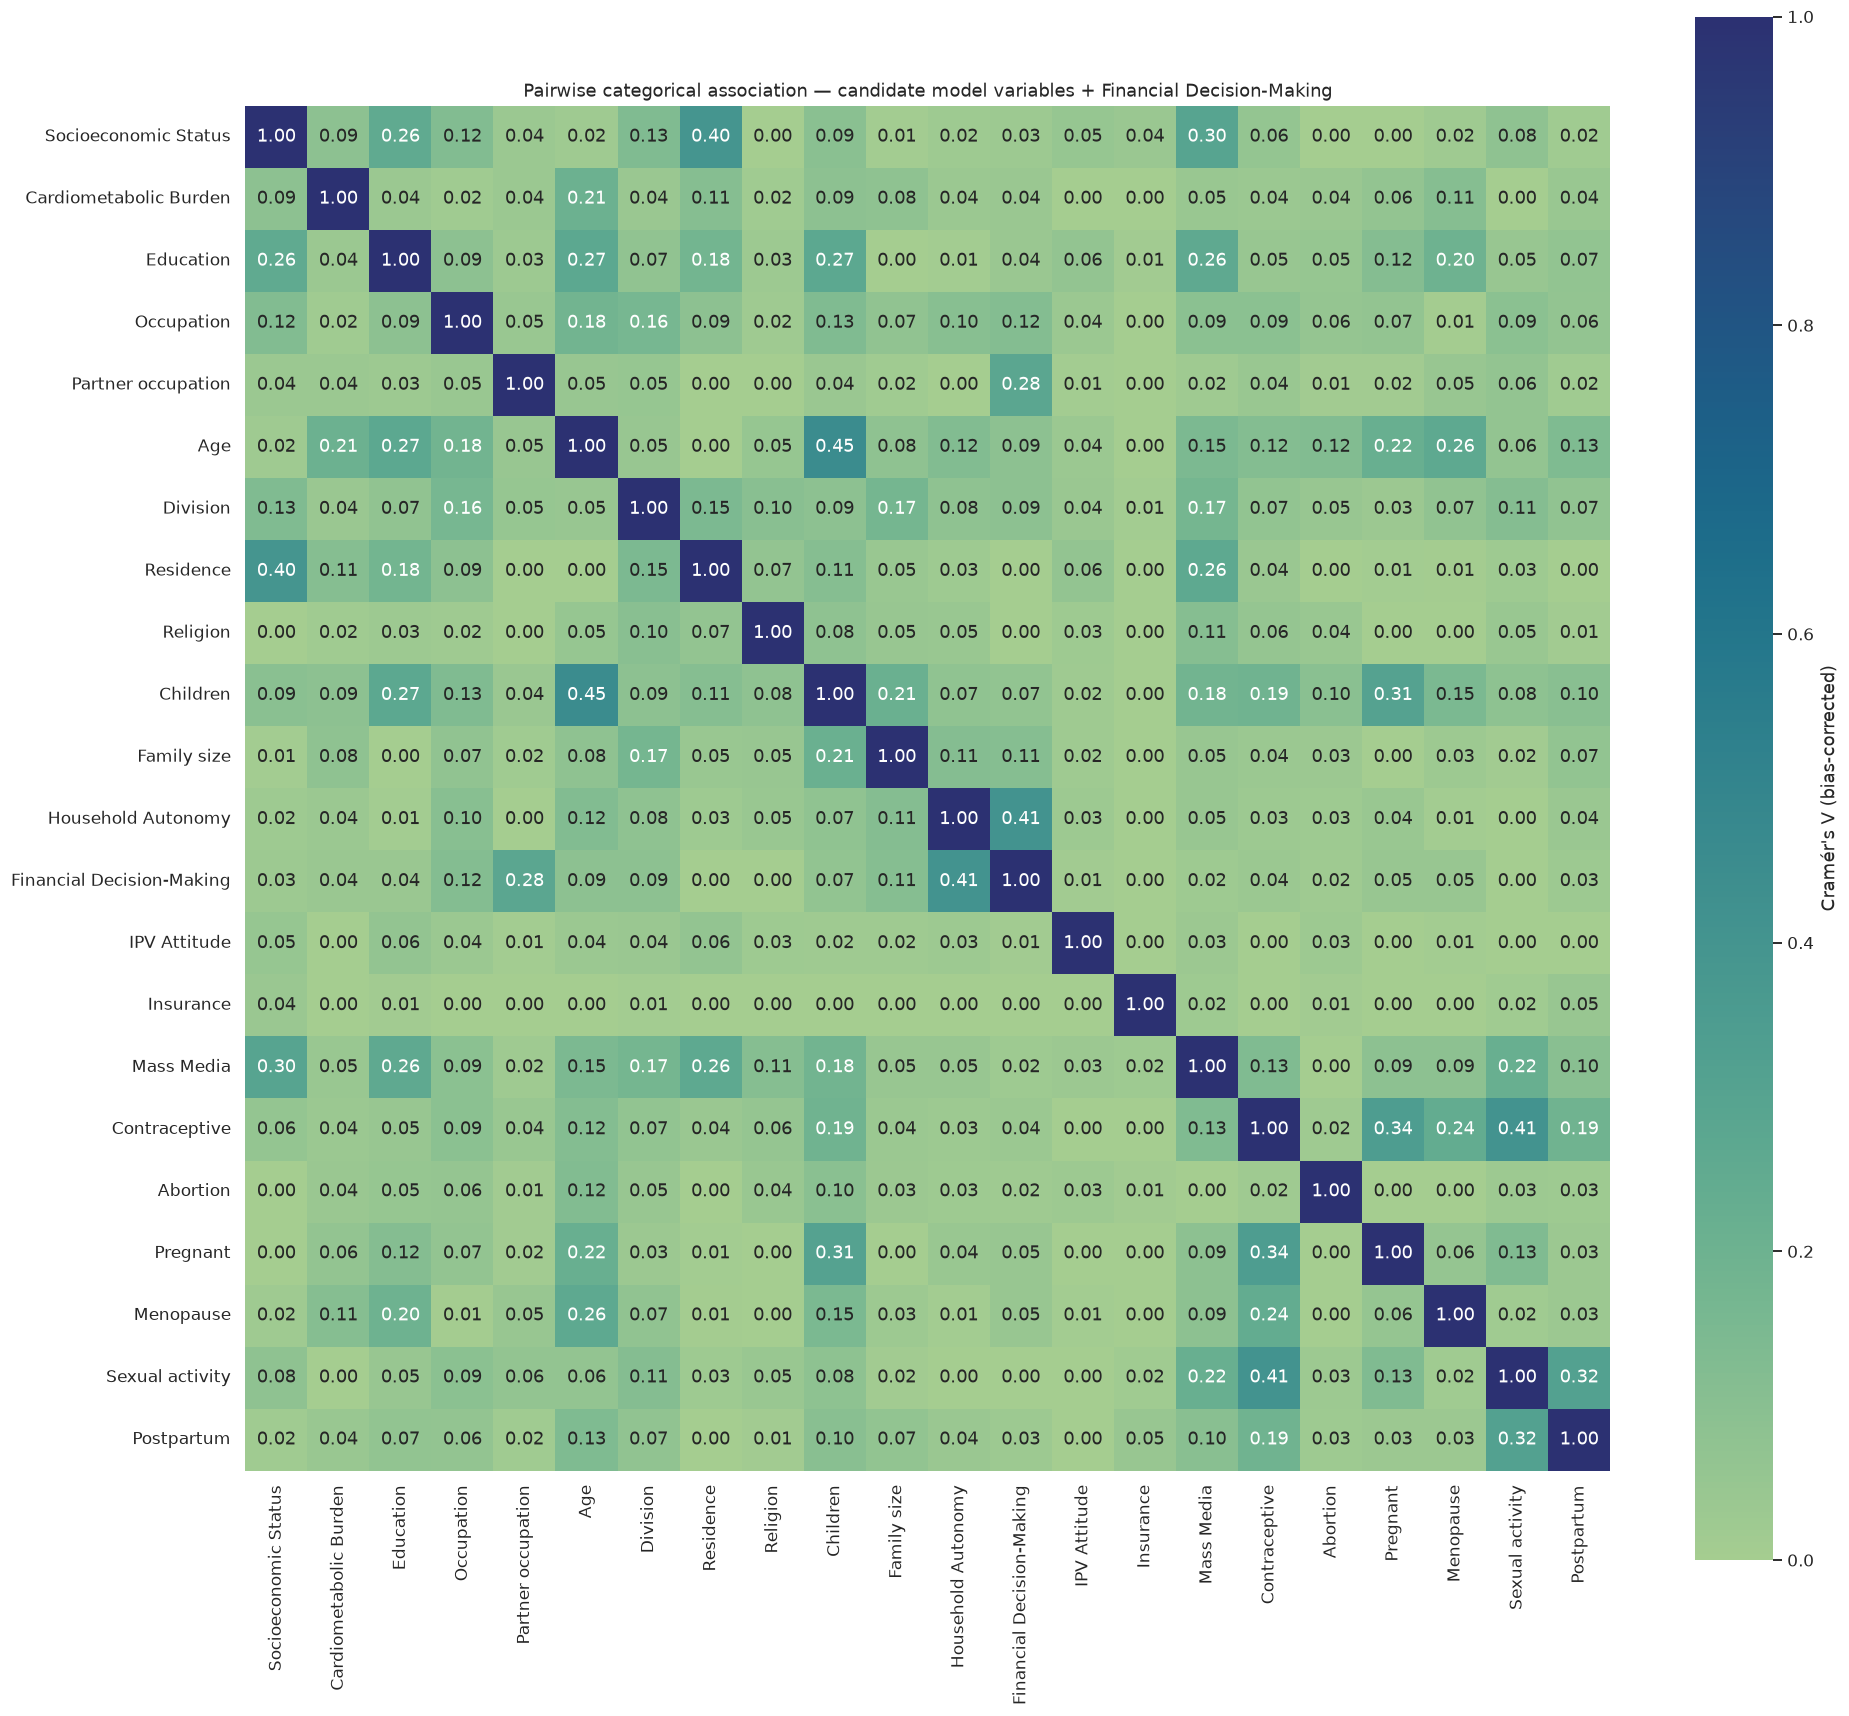

In [ ]:
def cramers_v_corrected(x, y):
    tab = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tab)[0]
    n = tab.sum().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

assoc_vars = model_vars
assoc = pd.DataFrame(index=assoc_vars, columns=assoc_vars, dtype=float)
for a in assoc_vars:
    for b in assoc_vars:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v_corrected(df[a], df[b])

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="crest", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Cramér's V (bias-corrected)"}, ax=ax)
plt.title("Pairwise categorical association — candidate model variables + Financial Decision-Making")
plt.tight_layout()
plt.show()

## Summary of Findings

